# Kria burn-segmentation — run, evaluate, report


In [1]:
!sudo pip3 install bitstring

In [6]:
# deploy folder
import os, sys, json, time, socket
import platform as _plat
import numpy as np

DEPLOY_DIR = os.path.expanduser("/home/ubuntu/kria_deploy/deploy-on-kria_input")

os.chdir(DEPLOY_DIR)
sys.path.insert(0, DEPLOY_DIR)
print("cwd :", os.getcwd())
print("euid:", os.geteuid())
print("files:", sorted(os.listdir(".")))
assert os.path.isfile("resizer.bit"), "resizer.bit missing — wrong DEPLOY_DIR?"

OUTDIR = os.path.join(DEPLOY_DIR, "results")
os.makedirs(OUTDIR, exist_ok=True)
print("results ->", OUTDIR)

cwd : /home/ubuntu/kria_deploy/deploy-on-kria_input
euid: 0
files: ['__pycache__', 'driver.py', 'driver_base.py', 'finn', 'fpga_test_inputs.npy', 'fpga_test_names.npy', 'qonnx', 'resizer.bit', 'resizer.hwh', 'results', 'run_seg.py', 'runtime_weights', 'unet_float.onnx', 'unet_int.onnx', 'validate.py']
results -> /home/ubuntu/kria_deploy/deploy-on-kria_input/results


In [13]:
# Read accelerator I/O from driver
from driver import io_shape_dict

def _first(x): return x[0] if isinstance(x, (list, tuple)) else x
ishape = tuple(int(d) for d in _first(io_shape_dict["ishape_normal"]))
oshape = tuple(int(d) for d in _first(io_shape_dict["oshape_normal"]))
idt    = _first(io_shape_dict["idt"])
odt    = _first(io_shape_dict["odt"])
H, W, C = ishape[1], ishape[2], ishape[3]
OUT_C   = oshape[-1]
print("accel input  :", ishape, idt, "(NHWC, fed as raw 0-255)")
print("accel output :", oshape, odt, "(raw pre-sigmoid logits)")

accel input  : (1, 64, 64, 3) UINT8 (NHWC, fed as raw 0-255)
accel output : (1, 64, 64, 1) INT32 (raw pre-sigmoid logits)


In [14]:
# Flash the bitstream
from driver_base import FINNExampleOverlay

FCLK_MHZ = 100.0
accel = FINNExampleOverlay(
    bitfile_name="resizer.bit",
    platform="zynq-iodma",
    io_shape_dict=io_shape_dict,
    batch_size=1,
    fclk_mhz=FCLK_MHZ,
    runtime_weight_dir="runtime_weights/",
)
print("overlay loaded @", FCLK_MHZ, "MHz")

overlay loaded @ 100.0 MHz


In [19]:
# picker
import numpy as np

batch = np.load("fpga_test_inputs.npy")                  # (N, 3, 64, 64) float32
try:
    names = np.load("fpga_test_names.npy")
except FileNotFoundError:
    names = None

idx = np.random.randint(len(batch))
np.save("input.npy", batch[idx].astype(np.float32))      # (3, 64, 64)

raw = np.load("input.npy")
print("aleasa: idx %d%s" % (idx, "" if names is None else "  (%s)" % names[idx]))
print("input.npy:", raw.shape, raw.dtype,
      "range", round(float(raw.min()), 4), round(float(raw.max()), 4))

aleasa: idx 3  (RGB_12.bmp)
input.npy: (3, 64, 64) float32 range 0.0811 0.9997


raw input.npy: (3, 64, 64) float32 range 0.0811 0.9997
prepared     : (1, 64, 64, 3) uint8 range 21 255


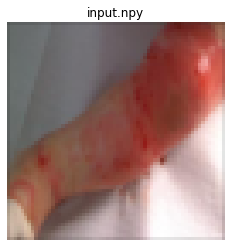

In [20]:
# Load input.npy, convert, visualize
import matplotlib.pyplot as plt

INPUT_NPY = "input.npy"
raw = np.load(INPUT_NPY)
print("raw input.npy:", raw.shape, raw.dtype, "range",
      round(float(raw.min()), 4), round(float(raw.max()), 4))

a = raw
if a.ndim == 4:
    a = a[0]
if a.ndim == 3 and a.shape[0] == C and a.shape[-1] != C:   # CHW -> HWC
    a = np.transpose(a, (1, 2, 0))
if a.ndim == 2:                       # HxW -> HxWx1
    a = a[..., None]
if np.issubdtype(a.dtype, np.floating) and a.max() <= 1.5:  # [0,1] -> [0,255]
    a = a * 255.0
a = np.clip(np.round(a), 0, 255).astype(np.uint8)
x = a[None, ...]                      # (1,H,W,C) NHWC uint8 == accel input
print("prepared     :", x.shape, x.dtype, "range", int(x.min()), int(x.max()))

disp = a if C == 3 else a[..., 0]
plt.figure(figsize=(4, 4))
plt.imshow(disp, cmap=None if C == 3 else "gray")
plt.title("input.npy"); plt.axis("off"); plt.show()

In [21]:
# Single inference -> raw output + value stats
out = accel.execute(x)
if isinstance(out, list):
    out = out[0]
out = np.asarray(out)
o = out[0] if out.shape[0] == 1 else out        # (H,W,C)
vals = o.reshape(-1)
print("raw output:", out.shape, out.dtype)
print("stats: min %s  max %s  mean %.3f" % (vals.min(), vals.max(), vals.mean()))
uq = np.unique(vals)
print("unique vals: %d  (first few: %s)" % (uq.size, uq[:12]))
np.save(os.path.join(OUTDIR, "raw_output.npy"), out)

raw output: (1, 64, 64, 1) float32
stats: min -176.0  max 146.0  mean -60.062
unique vals: 211  (first few: [-176. -171. -169. -164. -162. -157. -156. -155. -151. -150. -149. -148.])


mask: (64, 64) | foreground %: 32.18


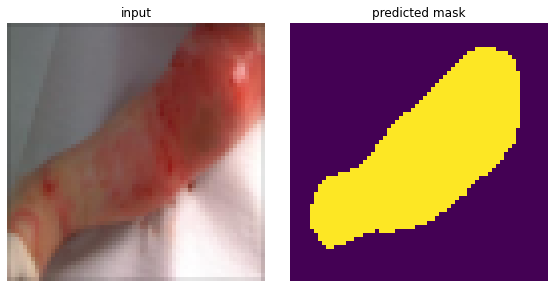

In [22]:
# mask and visualize side-by-side
THRESHOLD = 0.0   # raw output is pre-sigmoid

if OUT_C > 1:
    mask = np.argmax(o, axis=-1).astype(np.int32)
else:
    mask = (o[..., 0] > THRESHOLD).astype(np.int32)
print("mask:", mask.shape, "| foreground %%: %.2f" % (100.0 * (mask > 0).mean()))
np.save(os.path.join(OUTDIR, "pred_mask.npy"), mask)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(disp, cmap=None if C == 3 else "gray"); ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(mask, cmap="viridis"); ax[1].set_title("predicted mask"); ax[1].axis("off")
fig.tight_layout()
fig.savefig(os.path.join(OUTDIR, "input_vs_mask.png"), dpi=120)
plt.show()

In [9]:
# Inference timing latency + FINN throughput_test
WARMUP, RUNS = 5, 50
for _ in range(WARMUP):
    accel.execute(x)
t = np.empty(RUNS)
for i in range(RUNS):
    s = time.perf_counter(); accel.execute(x); t[i] = (time.perf_counter() - s) * 1e3
timing = dict(runs=RUNS, mean_ms=float(t.mean()), std_ms=float(t.std()),
              min_ms=float(t.min()), max_ms=float(t.max()), fps=float(1000.0 / t.mean()))
print("latency mean %.3f ms  (%.1f fps)" % (timing["mean_ms"], timing["fps"]))

finn_tp = {}
try:
    finn_tp = accel.throughput_test()
    print("throughput_test: %.1f images/s @ %s MHz"
          % (float(finn_tp.get("throughput[images/s]", float("nan"))),
             finn_tp.get("fclk[mhz]", "?")))
except Exception as e:
    finn_tp = {"error": str(e)}; print("throughput_test skipped:", e)

latency mean 1041.381 ms  (1.0 fps)
throughput_test: 11.3 images/s @ 99.999 MHz


In [10]:
# Inference timing (fast path: numpy INT32 unpack)
import numpy as np, time

# detect byte order against FINN
accel.copy_input_data_to_device(accel.pack_input(accel.fold_input(x, 0), 0), 0)
accel.execute_on_buffers()
accel.copy_output_data_from_device(accel.obuf_packed[0], 0)
_slow = accel.unpack_output(np.ascontiguousarray(accel.obuf_packed[0]), 0).reshape(accel.oshape_normal(0))
_p4 = np.ascontiguousarray(accel.obuf_packed[0]).reshape(-1, 4)
ENDIAN = next((k for k in (">i4", "<i4")
               if np.array_equal(_p4.view(k).reshape(accel.oshape_normal(0)), _slow)), ">i4")

def execute_fast(x):
    accel.copy_input_data_to_device(accel.pack_input(accel.fold_input(x, 0), 0), 0)
    accel.execute_on_buffers()
    accel.copy_output_data_from_device(accel.obuf_packed[0], 0)
    return np.ascontiguousarray(accel.obuf_packed[0]).reshape(-1, 4).view(ENDIAN).reshape(accel.oshape_normal(0))

# latency loop
WARMUP, RUNS = 5, 50
for _ in range(WARMUP):
    execute_fast(x)
t = np.empty(RUNS)
for i in range(RUNS):
    s = time.perf_counter(); execute_fast(x); t[i] = (time.perf_counter() - s) * 1e3
timing = dict(runs=RUNS, mean_ms=float(t.mean()), std_ms=float(t.std()),
              min_ms=float(t.min()), max_ms=float(t.max()), fps=float(1000.0 / t.mean()))
print("endianness: %s | latency mean %.3f ms  (%.1f fps)" % (ENDIAN, timing["mean_ms"], timing["fps"]))

# FINN throughput_test (hardware DMA path)
finn_tp = {}
try:
    finn_tp = accel.throughput_test()
    print("throughput_test: %.1f images/s @ %s MHz"
          % (float(finn_tp.get("throughput[images/s]", float("nan"))),
             finn_tp.get("fclk[mhz]", "?")))
except Exception as e:
    finn_tp = {"error": str(e)}; print("throughput_test skipped:", e)

endianness: <i4 | latency mean 89.499 ms  (11.2 fps)
throughput_test: 11.3 images/s @ 99.999 MHz


In [11]:
# Per-step latency breakdown of one execute() call
import time, numpy as np
for _ in range(5): accel.execute(x)                       # warmup

steps = ["fold_in","pack_in","copy_in","exec_hw","copy_out","unpack_out","unfold_out"]
acc = {k: [] for k in steps}; N = 20
for _ in range(N):
    t = [time.perf_counter()]
    fold = accel.fold_input(x, ind=0);                                t.append(time.perf_counter())
    pk   = accel.pack_input(fold, ind=0);                             t.append(time.perf_counter())
    accel.copy_input_data_to_device(pk, ind=0);                       t.append(time.perf_counter())
    accel.execute_on_buffers();                                       t.append(time.perf_counter())
    accel.copy_output_data_from_device(accel.obuf_packed[0], ind=0);  t.append(time.perf_counter())
    of = accel.unpack_output(accel.obuf_packed[0], ind=0);            t.append(time.perf_counter())
    _  = accel.unfold_output(of, ind=0);                              t.append(time.perf_counter())
    for k, a, b in zip(steps, t[:-1], t[1:]): acc[k].append((b-a)*1e3)

tot = 0.0; print("%-12s %10s" % ("step","mean ms"))
for k in steps:
    m = float(np.mean(acc[k])); tot += m; print("%-12s %10.3f" % (k, m))
print("%-12s %10.3f" % ("TOTAL", tot))

step            mean ms
fold_in           0.041
pack_in           0.056
copy_in           0.425
exec_hw          88.858
copy_out          0.250
unpack_out      948.414
unfold_out        0.050
TOTAL          1038.093


In [12]:
# Per-step latency breakdown of one execute() call — fast numpy INT32 unpack
import time, numpy as np

# detect byte order against FINN
accel.copy_input_data_to_device(accel.pack_input(accel.fold_input(x, 0), 0), 0)
accel.execute_on_buffers()
accel.copy_output_data_from_device(accel.obuf_packed[0], 0)
_slow = accel.unpack_output(np.ascontiguousarray(accel.obuf_packed[0]), 0).reshape(accel.oshape_normal(0))
_p4 = np.ascontiguousarray(accel.obuf_packed[0]).reshape(-1, 4)
ENDIAN = next((k for k in (">i4", "<i4")
               if np.array_equal(_p4.view(k).reshape(accel.oshape_normal(0)), _slow)), ">i4")
print("endianness:", ENDIAN)

for _ in range(5): accel.execute(x)                       # warmup

steps = ["fold_in","pack_in","copy_in","exec_hw","copy_out","unpack_out","unfold_out"]
acc = {k: [] for k in steps}; N = 20
oshape_n = accel.oshape_normal(0)
for _ in range(N):
    t = [time.perf_counter()]
    fold = accel.fold_input(x, ind=0);                                t.append(time.perf_counter())
    pk   = accel.pack_input(fold, ind=0);                             t.append(time.perf_counter())
    accel.copy_input_data_to_device(pk, ind=0);                       t.append(time.perf_counter())
    accel.execute_on_buffers();                                       t.append(time.perf_counter())
    accel.copy_output_data_from_device(accel.obuf_packed[0], ind=0);  t.append(time.perf_counter())
    of = np.ascontiguousarray(accel.obuf_packed[0]).reshape(-1, 4).view(ENDIAN);  t.append(time.perf_counter())
    _  = of.reshape(oshape_n);                                        t.append(time.perf_counter())
    for k, a, b in zip(steps, t[:-1], t[1:]): acc[k].append((b-a)*1e3)

tot = 0.0; print("%-12s %10s" % ("step","mean ms"))
for k in steps:
    m = float(np.mean(acc[k])); tot += m; print("%-12s %10.3f" % (k, m))
print("%-12s %10.3f" % ("TOTAL", tot))

endianness: <i4
step            mean ms
fold_in           0.045
pack_in           0.042
copy_in           0.314
exec_hw          88.825
copy_out          0.246
unpack_out        0.051
unfold_out        0.008
TOTAL            89.532


In [13]:
# True steady-state hardware throughput (pipelined over a batch)
import time
from driver_base import FINNExampleOverlay
B = 50
accel_b = FINNExampleOverlay(bitfile_name="resizer.bit", platform="zynq-iodma",
    io_shape_dict=io_shape_dict, batch_size=B, fclk_mhz=FCLK_MHZ,
    runtime_weight_dir="runtime_weights/", download=False)
accel_b.execute_on_buffers()                              # warmup / fill
t0 = time.perf_counter(); accel_b.execute_on_buffers(); dt = time.perf_counter() - t0
print("batch %d: %.3f s -> %.1f img/s, %.3f ms/frame steady-state" % (B, dt, B/dt, dt/B*1e3))

batch 50: 2.017 s -> 24.8 img/s, 40.330 ms/frame steady-state


In [15]:
# Inference timing: original UNet saved as ONNX ran on ARM
import time, numpy as np
try:
    import onnxruntime as ort
except ImportError:
    import subprocess; subprocess.run(["sudo","pip3","install","onnxruntime"], check=True)
    import onnxruntime as ort

ONNX_PATH, FPGA_HW_MS, WARMUP, RUNS = "unet_float.onnx", 88.0, 5, 50

xin = np.load("input.npy").astype(np.float32)
if xin.ndim == 3: xin = xin[None, ...]                       # (1,3,64,64)
xin = np.repeat(np.repeat(xin, 2, axis=2), 2, axis=3)        # -> (1,3,128,128)

def bench(threads):
    so = ort.SessionOptions(); so.intra_op_num_threads = threads; so.inter_op_num_threads = 1
    sess = ort.InferenceSession(ONNX_PATH, sess_options=so, providers=["CPUExecutionProvider"])
    iname = sess.get_inputs()[0].name
    for _ in range(WARMUP): sess.run(None, {iname: xin})
    t = np.empty(RUNS)
    for i in range(RUNS):
        s = time.perf_counter(); sess.run(None, {iname: xin}); t[i] = (time.perf_counter()-s)*1e3
    return float(t.mean()), float(t.std())

for label, thr in [("1 core",1), ("all cores",0)]:
    m, sd = bench(thr)
    print("ARM CPU (%-9s): %8.2f ms  (%.2f fps)   %.0fx vs FPGA hw" % (label, m, 1000.0/m, m/FPGA_HW_MS))

ARM CPU (1 core   ):   409.65 ms  (2.44 fps)   5x vs FPGA hw
ARM CPU (all cores):   122.42 ms  (8.17 fps)   1x vs FPGA hw


In [4]:
# Inference timing: INT UNet saved as ONNX ran on ARM
import time, numpy as np
try:
    import onnxruntime as ort
except ImportError:
    import subprocess; subprocess.run(["sudo","pip3","install","onnxruntime"], check=True)
    import onnxruntime as ort

ONNX_PATH, FPGA_HW_MS, WARMUP, RUNS = "unet_int.onnx", 88.0, 5, 50

xin = np.load("input.npy").astype(np.float32)
if xin.ndim == 3: xin = xin[None, ...]                       # (1,3,64,64)
xin = np.repeat(np.repeat(xin, 2, axis=2), 2, axis=3)        # -> (1,3,128,128)

def bench(threads):
    so = ort.SessionOptions(); so.intra_op_num_threads = threads; so.inter_op_num_threads = 1
    sess = ort.InferenceSession(ONNX_PATH, sess_options=so, providers=["CPUExecutionProvider"])
    iname = sess.get_inputs()[0].name
    for _ in range(WARMUP): sess.run(None, {iname: xin})
    t = np.empty(RUNS)
    for i in range(RUNS):
        s = time.perf_counter(); sess.run(None, {iname: xin}); t[i] = (time.perf_counter()-s)*1e3
    return float(t.mean()), float(t.std())

for label, thr in [("1 core",1), ("all cores",0)]:
    m, sd = bench(thr)
    print("ARM CPU (%-9s): %8.2f ms  (%.2f fps)   %.0fx vs FPGA hw" % (label, m, 1000.0/m, m/FPGA_HW_MS))

ARM CPU (1 core   ):   251.79 ms  (3.97 fps)   3x vs FPGA hw
ARM CPU (all cores):    75.15 ms  (13.31 fps)   1x vs FPGA hw


In [17]:
#power estimates FPGA
import glob, time, numpy as np

pw = sorted(glob.glob("/sys/class/hwmon/hwmon*/power1_input"))   # microwatts
def total_w():
    if pw:
        return sum(int(open(p).read()) for p in pw) / 1e6
    w = 0.0
    for h in glob.glob("/sys/class/hwmon/hwmon*"):
        for vi in glob.glob(h + "/in*_input"):
            ci = vi.replace("in", "curr").replace("_input", "_input")
            try: w += int(open(vi).read())/1000 * int(open(ci).read())/1000
            except Exception: pass
    return w

print("power sensors found:", pw or "(using V*I fallback)")
idle = np.mean([ (time.sleep(0.05), total_w())[1] for _ in range(30) ])

samples, t_end = [], time.perf_counter() + 3.0
while time.perf_counter() < t_end:
    accel.execute_on_buffers()
    samples.append(total_w())
load = np.mean(samples)
print("idle: %.2f W | under load: %.2f W | dynamic (accel): %.2f W" % (idle, load, load - idle))

power sensors found: ['/sys/class/hwmon/hwmon2/power1_input']
idle: 3.14 W | under load: 3.37 W | dynamic (accel): 0.23 W


In [18]:
#power estimates CPU

import glob
import threading
import time
import numpy as np
import onnxruntime as ort

PW = sorted(glob.glob("/sys/class/hwmon/hwmon*/power1_input"))

def total_w(): 
    return sum(int(open(p).read()) for p in PW) / 1e6

def measure(load_fn, secs=3.0, dt=0.01):
    buf, stop = [], threading.Event()
    def samp():
        while not stop.is_set(): 
            buf.append(total_w())
            time.sleep(dt)
    th = threading.Thread(target=samp)
    th.start()
    
    end = time.perf_counter() + secs
    while time.perf_counter() < end: 
        load_fn()
        
    stop.set()
    th.join()
    return float(np.mean(buf)), float(np.std(buf)), len(buf)


ONNX_PATH = "unet_float.onnx"
xin = np.load("input.npy").astype(np.float32)

if xin.ndim == 3: xin = xin[None, ...]
xin = np.repeat(np.repeat(xin, 2, axis=2), 2, axis=3) # shape (1,3,128,128)

so = ort.SessionOptions()
so.intra_op_num_threads = 0 
so.inter_op_num_threads = 1
sess = ort.InferenceSession(ONNX_PATH, sess_options=so, providers=["CPUExecutionProvider"])
iname = sess.get_inputs()[0].name

def run_onnx_load():
    sess.run(None, {iname: xin})

print("ONNX CPU execution")
for _ in range(3): 
    run_onnx_load()

print(f" idle ")
idle_m, idle_s, n1 = measure(lambda: time.sleep(0.01))

print(f" ONNX on ARM CPU ")
load_m, load_s, n2 = measure(run_onnx_load)

print("idle:          %.3f W (±%.3f, n=%d)" % (idle_m, idle_s, n1))
print("load (CPU):    %.3f W (±%.3f, n=%d)" % (load_m, load_s, n2))
print("dynamic delta: %.3f W" % (load_m - idle_m))

ONNX CPU execution
 idle 
 ONNX on ARM CPU 
idle:          3.160 W (±0.106, n=288)
load (CPU):    4.321 W (±0.109, n=274)
dynamic delta: 1.161 W


In [5]:
#power estimates CPU INT

import glob
import threading
import time
import numpy as np
import onnxruntime as ort

PW = sorted(glob.glob("/sys/class/hwmon/hwmon*/power1_input"))

def total_w(): 
    return sum(int(open(p).read()) for p in PW) / 1e6

def measure(load_fn, secs=3.0, dt=0.01):
    buf, stop = [], threading.Event()
    def samp():
        while not stop.is_set(): 
            buf.append(total_w())
            time.sleep(dt)
    th = threading.Thread(target=samp)
    th.start()
    
    end = time.perf_counter() + secs
    while time.perf_counter() < end: 
        load_fn()
        
    stop.set()
    th.join()
    return float(np.mean(buf)), float(np.std(buf)), len(buf)


ONNX_PATH = "unet_int.onnx"
xin = np.load("input.npy").astype(np.float32)

if xin.ndim == 3: xin = xin[None, ...]
xin = np.repeat(np.repeat(xin, 2, axis=2), 2, axis=3) # shape (1,3,128,128)

so = ort.SessionOptions()
so.intra_op_num_threads = 0 
so.inter_op_num_threads = 1
sess = ort.InferenceSession(ONNX_PATH, sess_options=so, providers=["CPUExecutionProvider"])
iname = sess.get_inputs()[0].name

def run_onnx_load():
    sess.run(None, {iname: xin})

print("ONNX CPU execution")
for _ in range(3): 
    run_onnx_load()

print(f" idle ")
idle_m, idle_s, n1 = measure(lambda: time.sleep(0.01))

print(f" ONNX on ARM CPU ")
load_m, load_s, n2 = measure(run_onnx_load)

print("idle:          %.3f W (±%.3f, n=%d)" % (idle_m, idle_s, n1))
print("load (CPU):    %.3f W (±%.3f, n=%d)" % (load_m, load_s, n2))
print("dynamic delta: %.3f W" % (load_m - idle_m))

ONNX CPU execution
 idle 
 ONNX on ARM CPU 
idle:          2.996 W (±0.110, n=288)
load (CPU):    4.201 W (±0.133, n=280)
dynamic delta: 1.205 W


In [17]:
#power estimates FPGA by rail
import glob, os
for h in sorted(glob.glob("/sys/class/hwmon/hwmon*")):
    name = open(h+"/name").read().strip() if os.path.exists(h+"/name") else "?"
    print(h, "->", name)
    for f in sorted(glob.glob(h+"/*_label") + glob.glob(h+"/power*_input")
                    + glob.glob(h+"/in*_input") + glob.glob(h+"/curr*_input")):
        try: print("   ", os.path.basename(f), "=", open(f).read().strip())
        except Exception: pass

import threading, time, numpy as np
PW = sorted(glob.glob("/sys/class/hwmon/hwmon*/power1_input"))
def total_w(): return sum(int(open(p).read()) for p in PW) / 1e6

def measure(load_fn, secs=3.0, dt=0.01):
    buf, stop = [], threading.Event()
    def samp():
        while not stop.is_set(): buf.append(total_w()); time.sleep(dt)
    th = threading.Thread(target=samp); th.start()
    end = time.perf_counter() + secs
    while time.perf_counter() < end: load_fn()
    stop.set(); th.join()
    return float(np.mean(buf)), float(np.std(buf)), len(buf)

idle_m, idle_s, n1 = measure(lambda: time.sleep(0.01))
load_m, load_s, n2 = measure(accel_b.execute_on_buffers)   # batch overlay keeps PL busy
print("idle: %.3f W (±%.3f, n=%d)" % (idle_m, idle_s, n1))
print("load: %.3f W (±%.3f, n=%d)" % (load_m, load_s, n2))
print("dynamic delta: %.3f W" % (load_m - idle_m))

/sys/class/hwmon/hwmon0 -> ams
    in10_input = 1798
    in11_input = 1206
    in12_input = 1787
    in13_input = 1789
    in14_input = 1785
    in15_input = 1787
    in16_input = 856
    in17_input = 1799
    in18_input = 599
    in19_input = 716
    in1_input = 1200
    in20_input = 1794
    in21_input = 1249
    in22_input = 0
    in23_input = 847
    in24_input = 844
    in25_input = 843
    in26_input = 1798
    in27_input = 597
    in2_input = 0
    in3_input = 715
    in4_input = 849
    in5_input = 1795
    in6_input = 1795
    in7_input = 842
    in8_input = 843
    in9_input = 843
/sys/class/hwmon/hwmon1 -> pwmfan
/sys/class/hwmon/hwmon2 -> ina260_u14
    curr1_input = 708
    in1_input = 5018
    power1_input = 3560000
idle: 3.418 W (±0.060, n=283)
load: 3.657 W (±0.028, n=94)
dynamic delta: 0.239 W


In [18]:
# Write report .txt + .json
report = dict(
    timestamp=time.strftime("%Y-%m-%d %H:%M:%S"),
    host=socket.gethostname(), euid=os.geteuid(), python=_plat.python_version(),
    bitfile=os.path.abspath("resizer.bit"), platform="zynq-iodma", fclk_mhz=FCLK_MHZ,
    input_file=os.path.abspath(INPUT_NPY),
    raw_input_shape=list(raw.shape), raw_input_dtype=str(raw.dtype),
    accel_input_shape=list(ishape), accel_input_dtype=str(idt),
    accel_output_shape=list(oshape), accel_output_dtype=str(odt),
    output_min=float(vals.min()), output_max=float(vals.max()), output_mean=float(vals.mean()),
    threshold=THRESHOLD, foreground_fraction=float((mask > 0).mean()),
    #metrics=metrics, timing=timing, finn_throughput_test=finn_tp,
    artifacts=["results/input_vs_mask.png", "results/pred_mask.npy", "results/raw_output.npy"],
)
txt = os.path.join(OUTDIR, "run_report.txt")
with open(txt, "w") as f:
    f.write("FINN Kria burn-segmentation run report\n")
    f.write(json.dumps(report, indent=2) + "\n")
with open(os.path.join(OUTDIR, "run_report.json"), "w") as f:
    json.dump(report, f, indent=2)
print(open(txt).read())
print("\nsaved everything under:", OUTDIR)
print("contents:", sorted(os.listdir(OUTDIR)))

FINN Kria burn-segmentation run report
{
  "timestamp": "2026-06-12 08:57:20",
  "host": "kria",
  "euid": 0,
  "python": "3.10.12",
  "bitfile": "/home/ubuntu/kria_deploy/deploy-on-kria_input/resizer.bit",
  "platform": "zynq-iodma",
  "fclk_mhz": 100.0,
  "input_file": "/home/ubuntu/kria_deploy/deploy-on-kria_input/input.npy",
  "raw_input_shape": [
    3,
    64,
    64
  ],
  "raw_input_dtype": "float32",
  "accel_input_shape": [
    1,
    64,
    64,
    3
  ],
  "accel_input_dtype": "UINT8",
  "accel_output_shape": [
    1,
    64,
    64,
    1
  ],
  "accel_output_dtype": "INT32",
  "output_min": -176.0,
  "output_max": 140.0,
  "output_mean": -113.81494140625,
  "threshold": 0.0,
  "foreground_fraction": 0.142822265625,
  "artifacts": [
    "results/input_vs_mask.png",
    "results/pred_mask.npy",
    "results/raw_output.npy"
  ]
}


saved everything under: /home/ubuntu/kria_deploy/deploy-on-kria_input/results
contents: ['input_vs_mask.png', 'pred_mask.npy', 'raw_output.npy',